# Barnes-Hut Algorithm — Examples & Guide

This notebook demonstrates the full API of the `barnes_hut` library:

1. **Quadtree basics** — building, inspecting, and visualizing the tree
2. **Force comparison** — Barnes-Hut vs direct O(N²) pairwise computation
3. **Galaxy simulation** — exponential disk with bulge
4. **Plummer sphere** — isotropic star cluster
5. **Performance benchmark** — how N scales with tree-based vs direct
6. **Energy conservation** — verifying the leapfrog integrator

---

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "Examples" else os.getcwd())

from barnes_hut import (
    Point, Rectangle, Quadtree, Simulation,
    build_tree, make_exponential_disk, make_plummer_sphere,
    make_random_uniform, make_solar_system,
    kinetic_energy, potential_energy, total_energy, total_momentum, center_of_mass,
    direct_nbody_step,
)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## 1. Quadtree Basics
### 1.1 Creating particles and a boundary

In [2]:
# Create a few particles by hand
p1 = Point(x=10, y=50, mass=10)
p2 = Point(x=49, y=49, mass=11)
p3 = Point(x=1,  y=1,  mass=12)
p4 = Point(x=3,  y=3,  mass=13)
p5 = Point(x=50, y=10, mass=14)

particles = [p1, p2, p3, p4, p5]
print(particles)

[Point(x=10, y=50, mass=10, vx=0, vy=0), Point(x=49, y=49, mass=11, vx=0, vy=0), Point(x=1, y=1, mass=12, vx=0, vy=0), Point(x=3, y=3, mass=13, vx=0, vy=0), Point(x=50, y=10, mass=14, vx=0, vy=0)]


### 1.2 Building a quadtree
The `build_tree()` function automatically computes a bounding box and inserts all particles:

In [3]:
tree = build_tree(particles, theta=0.5, capacity=1)
print(tree)

Quadtree(n=5, mass=60, com=(23.17, 20.5), depth=4, nodes=9)


### 1.3 Visualizing the tree structure

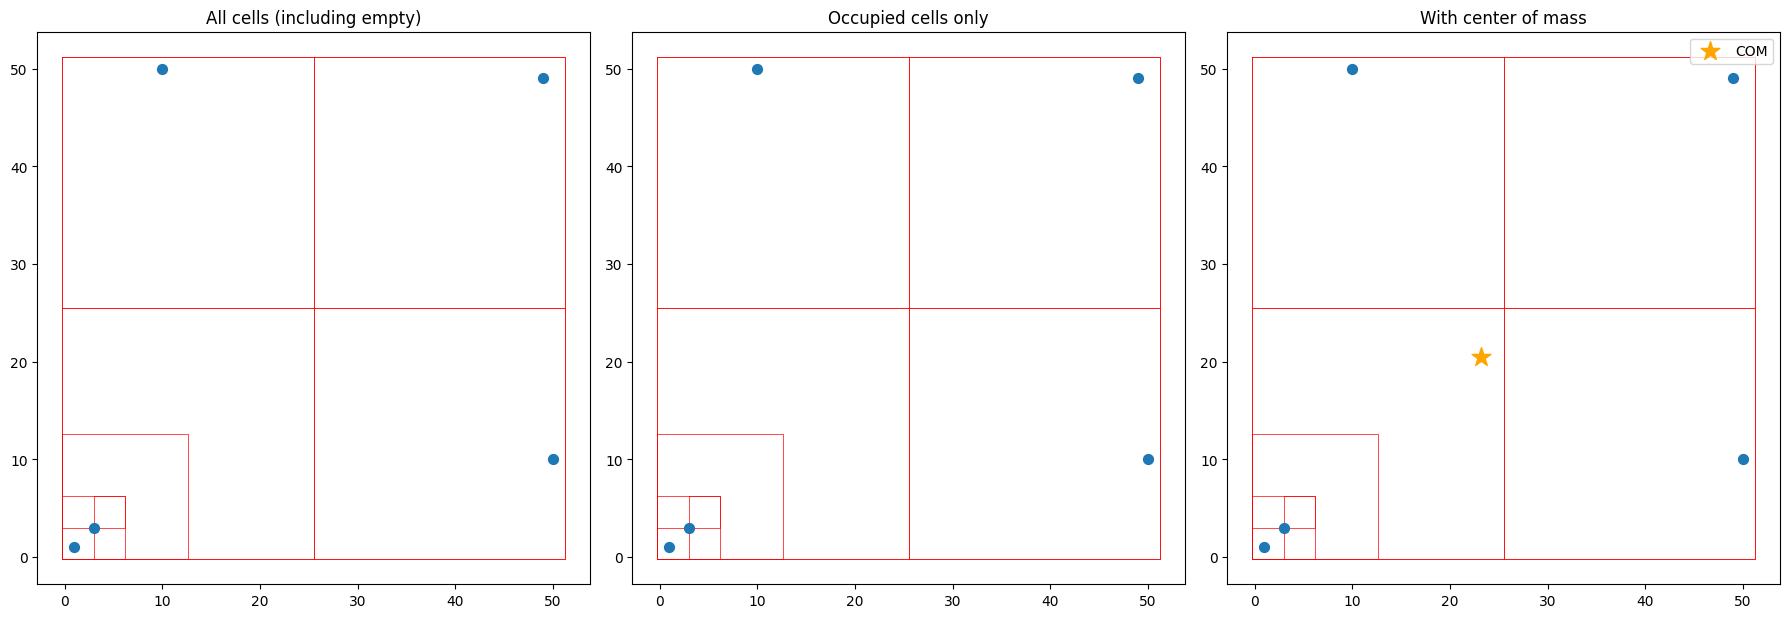

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# All cells
axes[0].set_title("All cells (including empty)")
axes[0].scatter([p.x for p in particles], [p.y for p in particles], s=50, zorder=5)
tree.draw(axes[0], show_empty=True)

# Only occupied cells
axes[1].set_title("Occupied cells only")
axes[1].scatter([p.x for p in particles], [p.y for p in particles], s=50, zorder=5)
tree.draw(axes[1], show_empty=False)

# With center of mass
axes[2].set_title("With center of mass")
axes[2].scatter([p.x for p in particles], [p.y for p in particles], s=50, zorder=5)
tree.draw(axes[2], show_empty=True)
tree.draw_com(axes[2], s=200, marker="*", color="orange", label="COM")
axes[2].legend()

for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 1.4 Accessing subtrees

Each node has `.nw`, `.ne`, `.sw`, `.se` properties for child quadrants:

In [8]:
# Access the southeast child
se = tree.se
print(f"SE quadrant: {se}")

# Access nested quadrants
sw = tree.sw
if sw is not None:
    print(f"SW quadrant: {sw}")
    print(f"SW center of mass: {sw.center_of_mass()}")
    print(f"SW total mass: {sw.mass}")

SE quadrant: Quadtree(n=1, mass=14, com=(50, 10), depth=0, nodes=1)
SW quadrant: Quadtree(n=2, mass=25, com=(2.04, 2.04), depth=3, nodes=5)
SW center of mass: (2.04, 2.04)
SW total mass: 25.0


### 1.5 Larger example with custom capacity

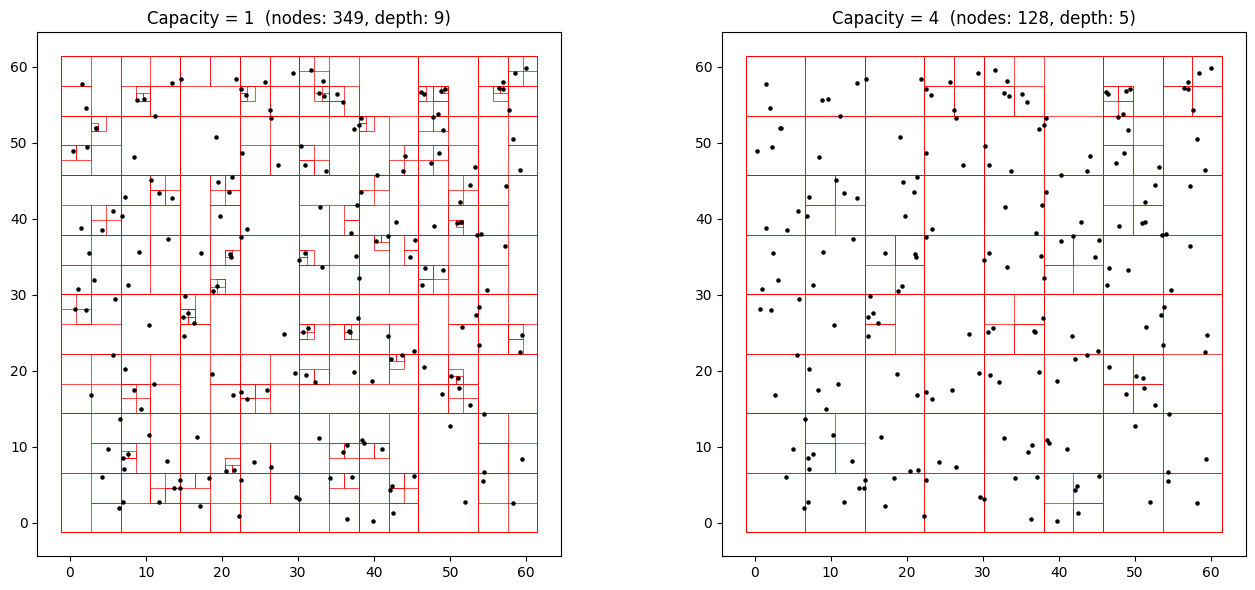

In [9]:
np.random.seed(42)
many_pts = [Point(x=np.random.uniform(0, 60), y=np.random.uniform(0, 60),
                  mass=np.random.uniform(1, 5)) for _ in range(200)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cap, title in [(axes[0], 1, "Capacity = 1"), (axes[1], 4, "Capacity = 4")]:
    t = build_tree(many_pts, theta=0.5, capacity=cap)
    ax.scatter([p.x for p in many_pts], [p.y for p in many_pts], s=5, c="black", zorder=5)
    t.draw(ax, show_empty=False)
    ax.set_title(f"{title}  (nodes: {t.count_nodes()}, depth: {t.depth()})")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 2. Force Comparison: Barnes-Hut vs Direct
Let's verify that the Barnes-Hut approximation matches the exact O(N²) result.

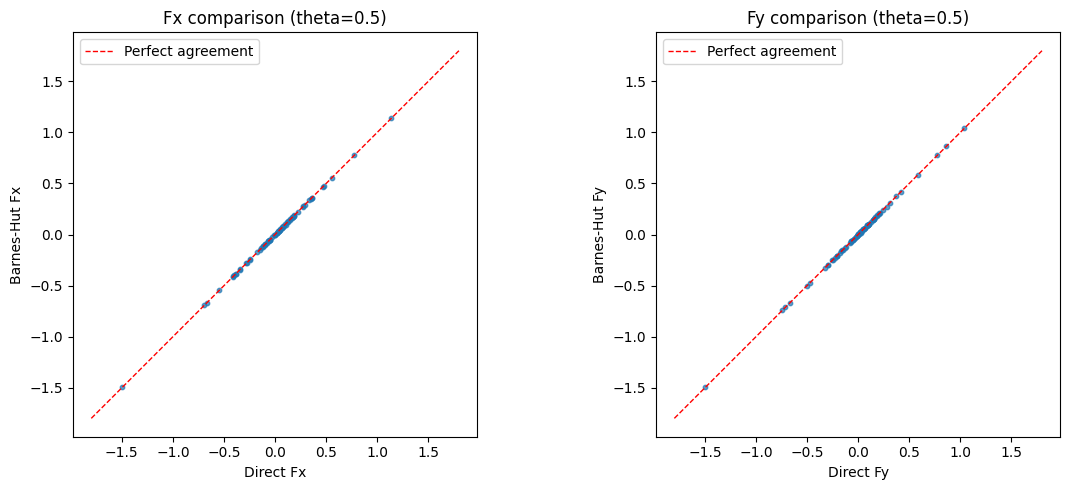

Mean relative force error: 1.2243%
Max  relative force error: 8.3336%


In [10]:
# Generate test particles
np.random.seed(7)
test_pts = make_random_uniform(n=80, width=50, seed=7)
G_test = 1.0
eps_test = 0.5

# Build tree
tree = build_tree(test_pts, theta=0.5, eps=eps_test)

# Compare forces on every particle
bh_fx, bh_fy = [], []
direct_fx, direct_fy = [], []

for i, p in enumerate(test_pts):
    # Barnes-Hut
    fx_bh, fy_bh = tree.compute_force(p, G_test)
    bh_fx.append(fx_bh)
    bh_fy.append(fy_bh)

    # Direct pairwise
    fx_d = fy_d = 0.0
    for j, q in enumerate(test_pts):
        if i == j:
            continue
        dx = q.x - p.x
        dy = q.y - p.y
        r2 = dx*dx + dy*dy + eps_test**2
        inv_r3 = 1.0 / (r2 * r2**0.5)
        f = G_test * p.mass * q.mass * inv_r3
        fx_d += f * dx
        fy_d += f * dy
    direct_fx.append(fx_d)
    direct_fy.append(fy_d)

bh_fx, bh_fy = np.array(bh_fx), np.array(bh_fy)
direct_fx, direct_fy = np.array(direct_fx), np.array(direct_fy)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, bh, direct, label in [(axes[0], bh_fx, direct_fx, "Fx"),
                                (axes[1], bh_fy, direct_fy, "Fy")]:
    lim = max(abs(direct).max(), 1e-10) * 1.2
    ax.scatter(direct, bh, s=10, alpha=0.7)
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="Perfect agreement")
    ax.set_xlabel(f"Direct {label}")
    ax.set_ylabel(f"Barnes-Hut {label}")
    ax.set_title(f"{label} comparison (theta=0.5)")
    ax.legend()
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Relative error
f_mag_direct = np.sqrt(direct_fx**2 + direct_fy**2)
err_fx = np.abs(bh_fx - direct_fx)
err_fy = np.abs(bh_fy - direct_fy)
rel_err = np.sqrt(err_fx**2 + err_fy**2) / np.maximum(f_mag_direct, 1e-30)
print(f"Mean relative force error: {rel_err.mean():.4%}")
print(f"Max  relative force error: {rel_err.max():.4%}")

## 3. Galaxy Simulation (Exponential Disk)
Generate a galaxy with a central bulge and a rotating exponential disk:

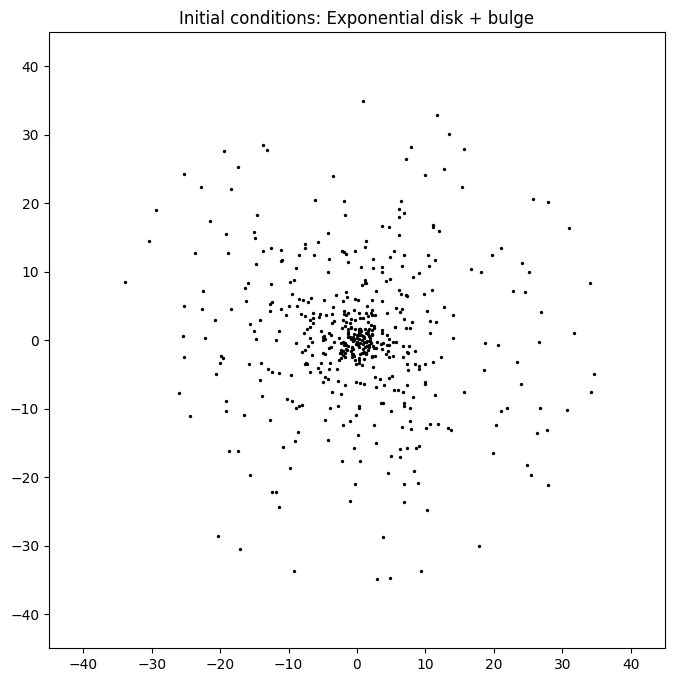

In [11]:
G_sim = 0.1
pts = make_exponential_disk(
    n=500,
    R_d=7.0,
    R_max=35.0,
    M_total=500.0,
    G=G_sim,
    bulge_frac=0.18,
    bulge_sigma=2.0,
    rotation=+1,
    v_dispersion=0.08,
    seed=42,
)
sim = Simulation(pts, G=G_sim, theta=0.6, eps=0.15, dt=0.06)

# Show initial state
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter([p.x for p in pts], [p.y for p in pts], s=2, c="black")
ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)
ax.set_aspect("equal")
ax.set_title("Initial conditions: Exponential disk + bulge")
plt.show()

### Run the simulation
Uncomment the `show=True` line to watch it live, or just run silently and inspect the final state:

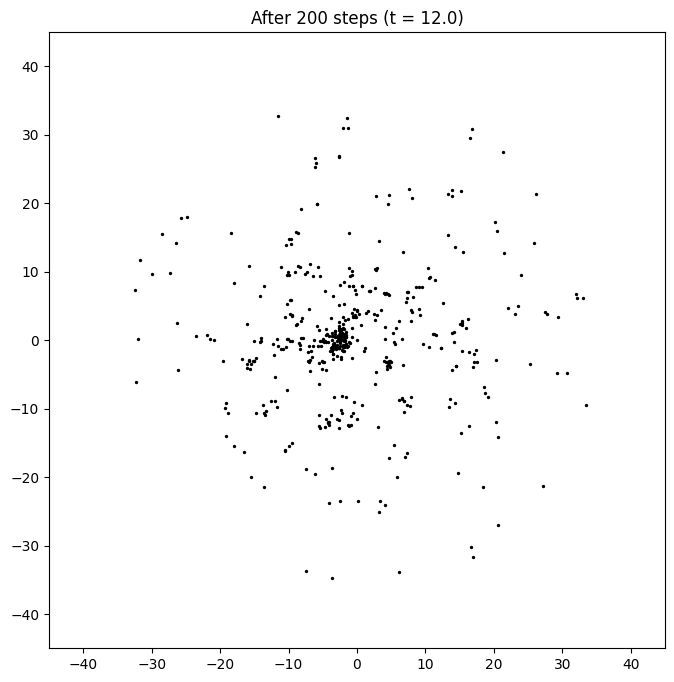

KE = 884.04
Momentum = (np.float64(-35.98126244391912), np.float64(0.47992385102441437))


In [12]:
# Run 200 steps silently
for _ in range(200):
    sim.step()

# Plot final state
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter([p.x for p in sim.particles], [p.y for p in sim.particles], s=2, c="black")
ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)
ax.set_aspect("equal")
ax.set_title(f"After {sim.frame} steps (t = {sim.time:.1f})")
plt.show()

print(f"KE = {sim.kinetic_energy():.2f}")
print(f"Momentum = {sim.total_momentum()}")

## 4. Plummer Sphere (Star Cluster)
The Plummer model is a standard test problem for N-body codes:

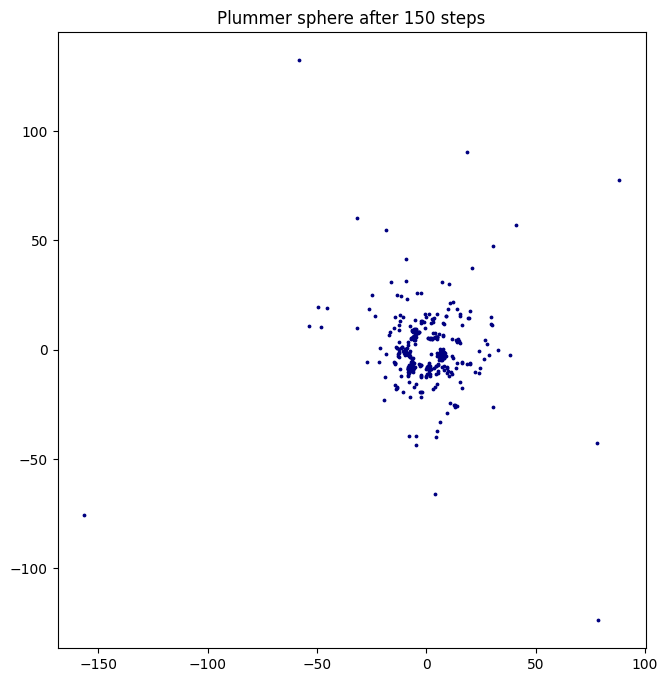

In [13]:
pts_plummer = make_plummer_sphere(n=400, M_total=200, a=8.0, G=0.1, seed=7)
sim_p = Simulation(pts_plummer, G=0.1, theta=0.5, eps=0.3, dt=0.08)

# Run and show final state
for _ in range(150):
    sim_p.step()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter([p.x for p in sim_p.particles], [p.y for p in sim_p.particles], s=3, c="navy")
ax.set_aspect("equal")
ax.set_title(f"Plummer sphere after {sim_p.frame} steps")
plt.show()

## 5. Performance Benchmark
Compare wall-clock time of Barnes-Hut vs direct O(N²) for increasing N:

N=   50  BH: 0.0040s  Direct: 0.0014s  Speedup: 0.4x
N=  100  BH: 0.0044s  Direct: 0.0045s  Speedup: 1.0x
N=  200  BH: 0.0127s  Direct: 0.0131s  Speedup: 1.0x
N=  500  BH: 0.0361s  Direct: 0.0962s  Speedup: 2.7x
N= 1000  BH: 0.1087s  Direct: 0.3621s  Speedup: 3.3x
N= 2000  BH: 0.2253s  Direct: 1.4612s  Speedup: 6.5x


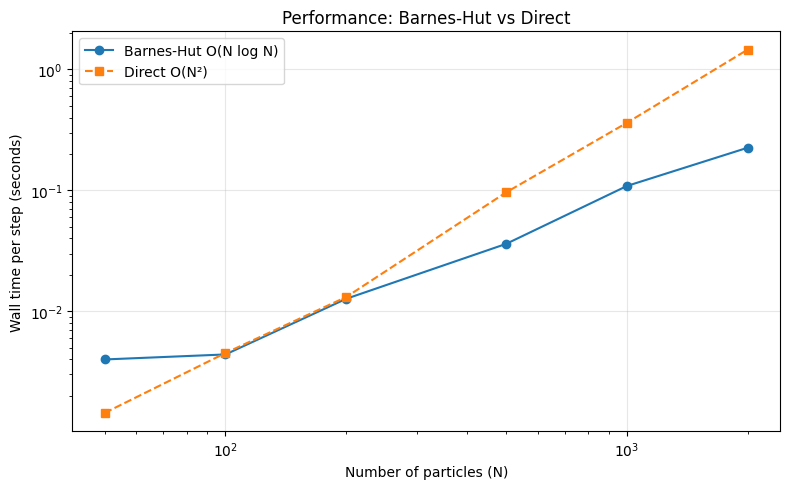

In [14]:
import time

Ns = [50, 100, 200, 500, 1000, 2000]
bh_times = []
direct_times = []

for n in Ns:
    pts_bench = make_random_uniform(n=n, width=100, seed=42)

    # Barnes-Hut: one step
    sim_bh = Simulation(pts_bench, G=0.1, theta=0.6, eps=0.5, dt=0.1)
    t0 = time.perf_counter()
    sim_bh.step()
    bh_times.append(time.perf_counter() - t0)

    # Direct: one step (re-create particles since step modifies in-place)
    pts_direct = make_random_uniform(n=n, width=100, seed=42)
    t0 = time.perf_counter()
    direct_nbody_step(pts_direct, dt=0.1, G=0.1, eps=0.5)
    direct_times.append(time.perf_counter() - t0)

    print(f"N={n:5d}  BH: {bh_times[-1]:.4f}s  Direct: {direct_times[-1]:.4f}s  Speedup: {direct_times[-1]/bh_times[-1]:.1f}x")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(Ns, bh_times,    "o-",  label="Barnes-Hut O(N log N)")
ax.loglog(Ns, direct_times, "s--", label="Direct O(N²)")
ax.set_xlabel("Number of particles (N)")
ax.set_ylabel("Wall time per step (seconds)")
ax.set_title("Performance: Barnes-Hut vs Direct")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Energy Conservation
A key test: total energy (KE + PE) should be approximately conserved
by the leapfrog integrator:

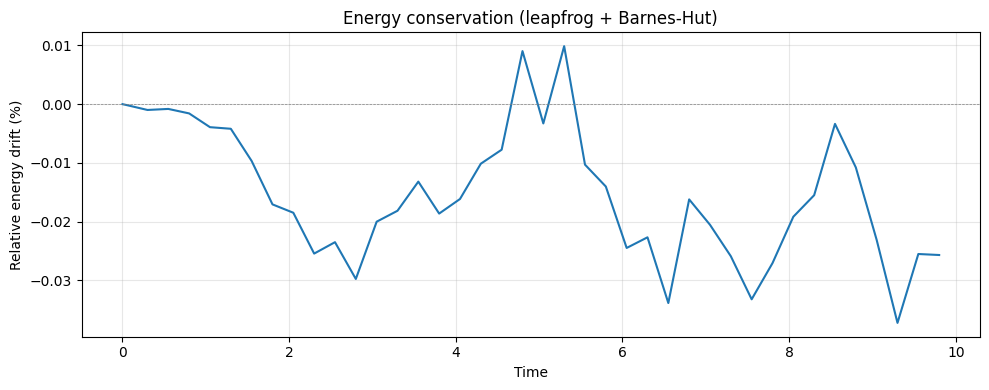

Initial energy: -98.1894
Final energy:   -98.2147
Drift: 0.03%


In [15]:
pts_energy = make_plummer_sphere(n=200, M_total=100, a=8.0, G=0.5, seed=99)
sim_e = Simulation(pts_energy, G=0.5, theta=0.5, eps=0.5, dt=0.05)

n_track = 200
energies = []
times = []

# Initial energy
energies.append(sim_e.total_energy())
times.append(sim_e.time)

for i in range(n_track):
    sim_e.step()
    if i % 5 == 0:  # sample every 5 steps to save time on PE calculation
        energies.append(sim_e.total_energy())
        times.append(sim_e.time)

energies = np.array(energies)
E0 = energies[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, (energies - E0) / abs(E0) * 100)
ax.set_xlabel("Time")
ax.set_ylabel("Relative energy drift (%)")
ax.set_title("Energy conservation (leapfrog + Barnes-Hut)")
ax.axhline(0, color="gray", ls="--", lw=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial energy: {E0:.4f}")
print(f"Final energy:   {energies[-1]:.4f}")
print(f"Drift: {abs(energies[-1] - E0) / abs(E0) * 100:.2f}%")

---
## What's next?

- **Increase N** and **decrease theta** to see accuracy vs speed tradeoffs
- **Try `save_video`** to export MP4 animations: `sim.run(300, save_video="galaxy.mp4")`
- **Use `callback`** to log custom diagnostics at each step
- **Extend the library** with your own initial condition generators